<img src="../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../images/Konstanz_Logo.svg" width="200" /> <img src="../images/KIT_Logo.png" width="200" />

# Visualization with hvPlot

Numbers in a table only take you so far. This chapter is about turning them into
pictures, and we look at **three** libraries that do it in very different ways —
hvPlot here, then matplotlib and Plotly in the notebooks that follow.

**hvPlot** is a *high-level* interface. It asks you for very little: hand it a
DataFrame, say which column goes on which axis, and it decides everything else.
That makes it the fastest way to get a usable plot on screen, and the right tool
when you are still exploring data rather than preparing a figure for publication.

It also does something the other two cannot: hvPlot does not draw anything itself.
It hands the work to a **backend** — Bokeh, Plotly or matplotlib — so the same one
line of code can produce an interactive plot or a static image, depending on which
backend is active.

> Further information: [hvplot.holoviz.org](https://hvplot.holoviz.org/)

---

## Contents

1. [The data](#data)
2. [A first plot](#first)
3. [Choosing a backend](#backends)
4. [Grouping data into a dropdown](#groupby)
5. [Subplots](#subplots)

<a id="data"></a>
## 1. The data

All three notebooks in this chapter use the same small table: **eight university
cities in Baden-Württemberg**, one row each.

| Column | Meaning |
|---|---|
| **Name** | Name of the city |
| **Population** | Number of inhabitants |
| **Area** | Area of the city in km² |
| **Students** | Number of enrolled students |
| **Percentage** | Students as a percentage of the population |

It is deliberately tiny. Eight rows fit on screen in full, so at every step you can
check the plot against the numbers that produced it.

In [1]:
import pandas as pd

df = pd.read_csv("University_Cities.csv")
df

,Name,Population,Area,Students,Percentage
0,Freiburg,230241,153.04,32677,14.19
1,Heidelberg,160355,108.83,36274,22.62
2,Karlsruhe,313092,173.42,37565,12.00
3,Konstanz,84911,54.12,16740,19.71
4,Mannheim,309370,144.97,28183,9.11
5,Stuttgart,634830,207.32,53870,8.49
6,Tübingen,92811,108.06,28010,30.18
7,Ulm,126329,118.68,13296,10.52


<a id="first"></a>
## 2. A first plot

hvPlot attaches itself to pandas. Importing `hvplot.pandas` adds a `.hvplot`
accessor to every DataFrame — after that, plotting is a method call on the data
itself.

In [2]:
import hvplot.pandas

In [3]:
df.hvplot.bar(x="Name", y="Population")

:Bars   [Name]   (Population)

One line, and the result is **interactive**: hover over a bar to read its value,
and use the toolbar on the right to zoom or pan.

That interactivity comes from the backend, not from hvPlot.

<a id="backends"></a>
## 3. Choosing a backend

By default hvPlot draws through **Bokeh**. `hvplot.extension` switches to a
different one, and the same plotting call then produces a different kind of object.

First Plotly — also interactive, but with its own toolbar and styling.

In [4]:
hvplot.extension('plotly')

df.hvplot.bar(x="Name", y="Population")

:Bars   [Name]   (Population)

And now matplotlib, whose output is a **static image**: no hovering, no zooming,
just a picture.

:Bars   [Name]   (Population)
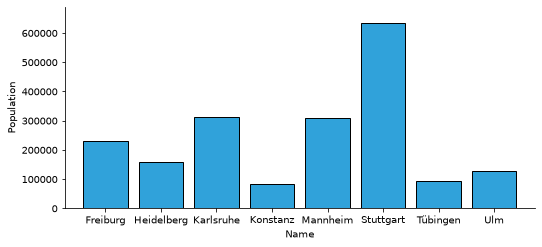

In [5]:
hvplot.extension('matplotlib')

df.hvplot.bar(x="Name", y="Population")

Careful with this: the switch is **global and permanent**. Every plot from here on
uses whichever backend was set last, not just the next one.

The line plot below is still matplotlib, because that is what we selected above —
even though nothing in this cell says so.

:Curve   [Name]   (Population)
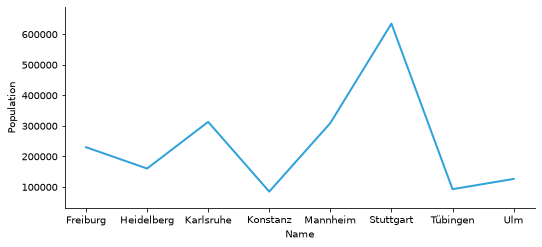

In [6]:
df.hvplot.line(x="Name", y="Population")

Switching back to Bokeh makes the very same call interactive again.

In [7]:
hvplot.extension('bokeh')

df.hvplot.line(x="Name", y="Population")

:Curve   [Name]   (Population)

<a id="groupby"></a>
## 4. Grouping data into a dropdown

`groupby` splits the data by a column and gives you a **drop-down menu** to move
between the groups, rather than drawing everything at once. It is the hvPlot
feature that most clearly repays being interactive.

To show it off we sort the cities by population and add one artificial column —
the number of letters in each city name — so that there is something to group by
that puts several cities in the same bucket.

In [8]:
df_sorted = df.sort_values(by="Population", ascending=True)
df_sorted["NumLetters"] = df_sorted["Name"].str.len()

df_sorted

,Name,Population,Area,Students,Percentage,NumLetters
3,Konstanz,84911,54.12,16740,19.71,8
6,Tübingen,92811,108.06,28010,30.18,8
7,Ulm,126329,118.68,13296,10.52,3
1,Heidelberg,160355,108.83,36274,22.62,10
0,Freiburg,230241,153.04,32677,14.19,8
4,Mannheim,309370,144.97,28183,9.11,8
2,Karlsruhe,313092,173.42,37565,12.00,9
5,Stuttgart,634830,207.32,53870,8.49,9


Now a bar chart of population and student numbers, with one entry per city in the
drop-down.

In [9]:
df_sorted.hvplot.bar(y=["Population", "Students"],
                     width=500,
                     groupby="Name")

:DynamicMap   [Name]
   :Bars   [index,Variable]   (value)

Grouping by `NumLetters` instead puts every city whose name has the same length
into the same view — so some entries in the menu now show several bars at once.

In [10]:
df_sorted.hvplot.bar(y=["Area"],
                     x="Name",
                     width=500,
                     groupby="NumLetters")

:DynamicMap   [NumLetters]
   :Bars   [Name,Variable]   (value)

<a id="subplots"></a>
## 5. Subplots

Passing several columns to `y` with `subplots=True` draws each one in its own panel,
and `.cols(2)` arranges them two per row.

`shared_axes=False` matters here: the four quantities are on completely different
scales, and without it hvPlot would force them onto a common axis and flatten three
of the four plots.

In [11]:
plots = df_sorted.hvplot.bar(x="Name",
                             y=["Population", "Area", "Students", "Percentage"],
                             subplots=True,
                             shared_axes=False,
                             width=500).cols(2)

plots

:NdLayout   [Variable]
   :Bars   [Name]   (value)

Note that hvPlot orders the panels **alphabetically**, not in the order you listed
the columns.

Each panel is a plot object in its own right, so looping over them lets you set
options individually — here a different colour for each.

In [12]:
my_colors = ["blue", "red", "orange", "cyan"]

for i, subplot in enumerate(plots):
    subplot.opts(color=my_colors[i])

plots

:NdLayout   [Variable]
   :Bars   [Name]   (value)

`.cols(1)` stacks them in a single column instead. Dropping `Area` leaves three
panels, and the colours are matched to the ones they had above — `Percentage` red,
`Population` orange, `Students` cyan.

In [13]:
plots = df_sorted.hvplot.bar(x="Name",
                             y=["Population", "Students", "Percentage"],
                             subplots=True,
                             shared_axes=False,
                             width=500).cols(1)

my_colors = ["red", "orange", "cyan"]

for i, subplot in enumerate(plots):
    subplot.opts(color=my_colors[i])

plots

:NdLayout   [Variable]
   :Bars   [Name]   (value)

That is most of what hvPlot is for: a DataFrame, one method call, and a usable
interactive plot.

What it does *not* give you is fine control. When you need to place every element
exactly — for a paper, a poster, a thesis — you reach for matplotlib, which is the
subject of the next notebook.